# Задача 6. BFS on GPU

## Трубачеев Борис Андреевич, группа S4101

### Выполнены все подпункты задания.

Скачиваем opencl

In [1]:
pip install pyopencl

Note: you may need to restart the kernel to use updated packages.


Обычная реализация BFS

In [2]:
from collections import deque
import numpy as np


def bfs_orders(G, source):
    n = G.shape[0]
    visited = np.zeros(n, dtype=np.int32)
    order = np.empty(n, dtype=np.int32)
    predecessors = np.full(
        n,
        -1,
        dtype=np.int32
    )

    distance = np.full(
        n,
        -1,
        dtype=np.int32
    )

    queue = deque([source])
    visited[source] = 1
    distance[source] = 0
    next_in_order = 0

    while queue:
        node = queue.popleft()
        order[next_in_order] = node
        next_in_order += 1
        start = G.indptr[node]
        end = G.indptr[node + 1]
        
        for neighbor in G.indices[start:end]:
            if visited[neighbor] == 0:
                visited[neighbor] = 1
                predecessors[neighbor] = node
                distance[neighbor] = distance[node] + 1
                queue.append(neighbor)

    order.resize(next_in_order)

    return distance

Создание контекста и очереди команд и проверка устройства

In [3]:
import pyopencl as cl
import numpy as np
import scipy.sparse as sp
import os

os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'

platform = cl.get_platforms()[0]

print("Platform:", platform.name)

context = cl.Context(
    dev_type=cl.device_type.GPU,
    properties=[
        (cl.context_properties.PLATFORM, platform)
    ]
)

queue = cl.CommandQueue(context)

print("Device:", queue.device.name)

Platform: NVIDIA CUDA
Device: NVIDIA GeForce RTX 5060 Ti


Создание и компиляция OpenCL ядра для выполнения одного шага DFS на GPU

In [4]:
cl_program = cl.Program(context, """
__kernel void bfs_orders(
    __global const int* indptr,
    __global const int* indices,
    const int write_offset,
    __global int* order,
    __global int* predecessors,
    __global int* distance,
    __global int* visited,
    __global int* queue,
    const int queue_size,
    __global int* queue_next,
    __global int* queue_next_size,

    const int level
)
{
    int i = get_global_id(0);
    if (i < queue_size)
    {
        int node = queue[i];
        order[write_offset + i] = node;
        for (int j = indptr[node];
             j < indptr[node + 1];
             j++)
        {
            int neighbor = indices[j];
            if (atomic_cmpxchg(
                    &visited[neighbor],
                    0,
                    1
                ) == 0)
            {
                int pos =
                    atomic_inc(queue_next_size);
                queue_next[pos] = neighbor;
                predecessors[neighbor] = node;
                distance[neighbor] = level + 1;
            }
        }
    }
}
""").build()

Функция реализации bfs на GPU, использующая ядро OpenCL

In [5]:
def bfs_orders_cl(G_cl, source):
    cl_flags_rw = cl.mem_flags.READ_WRITE

    n = G_cl['shape'][0]
    int_size = np.dtype(np.int32).itemsize

    cl_visited = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_order = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_predecessors = cl.Buffer(context, cl_flags_rw, size=n * int_size) 
    cl_distance = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue_next = cl.Buffer(context,cl_flags_rw, size=n * int_size) 
    cl_queue_next_size = cl.Buffer(context,cl_flags_rw, size=int_size)    

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(0), offset=0, size=n * int_size)
    cl.enqueue_fill_buffer(queue, cl_predecessors, np.int32(-1), offset=0, size=n * int_size)
    cl.enqueue_fill_buffer(queue, cl_distance, np.int32(-1), offset=0, size=n * int_size)
    cl.enqueue_fill_buffer(queue, cl_distance, np.int32(0), offset=source * int_size, size=int_size)
    
    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(1), offset=source * int_size, size=int_size)
    cl.enqueue_copy(queue, cl_queue, np.array([source], dtype=np.int32))

    cpu_queue_next_size = np.empty(1, dtype=np.int32)

    queue_size = 1
    write_offset = 0
    level = 0
    while queue_size > 0:   
        cl.enqueue_fill_buffer(queue, cl_queue_next_size, np.int32(0), offset=0, size=int_size)

        cl_program.bfs_orders(
            queue,(queue_size,),None,
            G_cl['indptr'], G_cl['indices'],
            np.int32(write_offset), cl_order, cl_predecessors,
            cl_distance, cl_visited, cl_queue,
            np.int32(queue_size), cl_queue_next,
            cl_queue_next_size, np.int32(level)
        )

        write_offset += queue_size

        cl.enqueue_copy(queue, cpu_queue_next_size, cl_queue_next_size)
        queue_size = cpu_queue_next_size[0]

        if queue_size > 0:
            cl_queue, cl_queue_next = cl_queue_next, cl_queue

        level += 1

    order = np.empty(n, dtype=np.int32)
    predecessors = np.empty(n, dtype=np.int32)   
    cl.enqueue_copy(queue, order, cl_order)
    cl.enqueue_copy(queue, predecessors, cl_predecessors)
    distance = np.empty(n, dtype=np.int32)
    cl.enqueue_copy(queue, distance, cl_distance)
    
    return distance

Функция переноса графа на GPU, чтобы сравнивать с CPU реализацией на одних и тех же графах

In [6]:
def make_gpu_graph(G_csr):

    return dict(
        indptr=cl.Buffer(
            context,
            cl.mem_flags.READ_ONLY |
            cl.mem_flags.COPY_HOST_PTR,
            hostbuf=G_csr.indptr.astype(np.int32)
        ),

        indices=cl.Buffer(
            context,
            cl.mem_flags.READ_ONLY |
            cl.mem_flags.COPY_HOST_PTR,
            hostbuf=G_csr.indices.astype(np.int32)
        ),

        data=cl.Buffer(
            context,
            cl.mem_flags.READ_ONLY |
            cl.mem_flags.COPY_HOST_PTR,
            hostbuf=G_csr.data.astype(np.float32)
        ),

        shape=np.array(
            G_csr.shape,
            dtype=np.int32
        )
    )

Функция бенчмаркинга для реалзаций bfs на cpu и gpu. 

Каждый граф с SuiteSparse Matrix Collection считывается из папки и переносится на GPU, затем прогоняется bfs прогоняется по 5 раз на GPU и CPU и в датафрейм пишутся средние значения времени работы.

Для проверки корректности реализации, для каждого графа сравниваются полученные дистанции и в итоговой датафрейм записывается True, если ответы одни, и False, если ответы разные

In [7]:
import os
import time
import numpy as np
import pandas as pd
import scipy as sp


def benchmark_graphs(
    graphs_dir,
    bfs_cpu,
    bfs_gpu,
    make_gpu_graph,
    source=0,
    n_runs=5
):

    results = []

    files = sorted([
        f for f in os.listdir(graphs_dir)
        if f.endswith(".mtx")
    ])

    print(f"Found {len(files)} graphs\n")

    for filename in files:
        if filename == 'delaunay_n24.mtx':
            continue
        print("=" * 60)
        print(filename)

        graph_path = os.path.join(
            graphs_dir,
            filename
        )

        try:

            G_csr = sp.io.mmread(
                graph_path
            ).tocsr()

        except Exception as e:

            print("Load error:", e)
            continue

        n_vertices = G_csr.shape[0]
        n_edges = G_csr.nnz

        print(
            f"nodes={n_vertices:,} "
            f"edges={n_edges:,}"
        )

        G_gpu = make_gpu_graph(G_csr)
        
        #замеры для СPU
        cpu_times = []

        order_cpu = None
        pred_cpu = None

        for _ in range(n_runs):

            start = time.perf_counter()

            dist_cpu = bfs_cpu(
                G_csr,
                source
            )

            cpu_times.append(
                time.perf_counter() - start
            )

        cpu_time = np.mean(cpu_times)

        #замеры для GPU
        gpu_times = []

        order_gpu = None
        pred_gpu = None

        for _ in range(n_runs):

            start = time.perf_counter()

            dist_gpu = bfs_gpu(
                G_gpu,
                source
            )

            gpu_times.append(
                time.perf_counter() - start
            )

        gpu_time = np.mean(gpu_times)

        #считаем корректность
        distances_equal = np.array_equal(dist_cpu, dist_gpu)
        
        speedup = (
            cpu_time / gpu_time
            if gpu_time > 0
            else np.nan
        )
        density = n_edges / (n_vertices * (n_vertices - 1))
        
        results.append({
            "graph": filename,
            "nodes": n_vertices,
            "edges": n_edges,
            "density": density,
            "cpu_time": cpu_time,
            "gpu_time": gpu_time,
            "speedup": speedup,
            "distances_equal": distances_equal
        })

    return pd.DataFrame(results)

Запускаем бенчмаркинг

In [8]:
results_df = benchmark_graphs(
    graphs_dir="../Graph Analysis/Lab2/graphs",
    bfs_cpu=bfs_orders,
    bfs_gpu=bfs_orders_cl,
    make_gpu_graph=make_gpu_graph,
    source=0,
    n_runs=10
)

print(results_df)

Found 15 graphs

NACA0015.mtx
nodes=1,039,183 edges=6,229,636


C:\Users\boris\AppData\Local\Temp\ipykernel_21140\2753587686.py:31: RepeatedKernelRetrieval: Kernel 'bfs_orders' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  cl_program.bfs_orders(


ca-GrQc.mtx
nodes=5,242 edges=28,980
dblp-2010.mtx
nodes=326,186 edges=1,615,400
delaunay_n14.mtx
nodes=16,384 edges=98,244
delaunay_n15.mtx
nodes=32,768 edges=196,548
email.mtx
nodes=1,133 edges=10,902
fxm3_6.mtx
nodes=5,026 edges=94,026
italy_osm.mtx
nodes=6,686,493 edges=14,027,956
mycielskian10.mtx
nodes=767 edges=44,392
net25.mtx
nodes=9,520 edges=401,200
opt1.mtx
nodes=15,449 edges=1,930,655
rajat06.mtx
nodes=10,922 edges=46,983
vsp_data_and_seymourl.mtx
nodes=9,167 edges=111,732
wing_nodal.mtx
nodes=10,937 edges=150,976
                        graph    nodes     edges       density  cpu_time  \
0                NACA0015.mtx  1039183   6229636  5.768714e-06  1.679755   
1                 ca-GrQc.mtx     5242     28980  1.054841e-03  0.000024   
2               dblp-2010.mtx   326186   1615400  1.518276e-05  0.350903   
3            delaunay_n14.mtx    16384     98244  3.660098e-04  0.024228   
4            delaunay_n15.mtx    32768    196548  1.830552e-04  0.049595   
5          

Видим, что ответы для всех графах одинаковые, значит GPU реализация корректная

Также видим, что почти везде GPU дает ускоерние (колонка speedup), кроме 3 графов. Максимальное ускорение было достигнуто в 30 раз. 

Построим графики зависимостей от параметров графа:

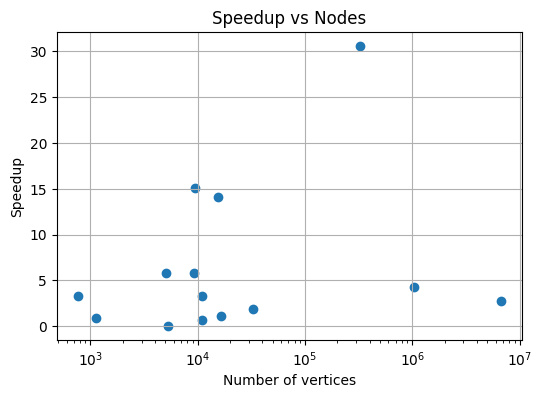

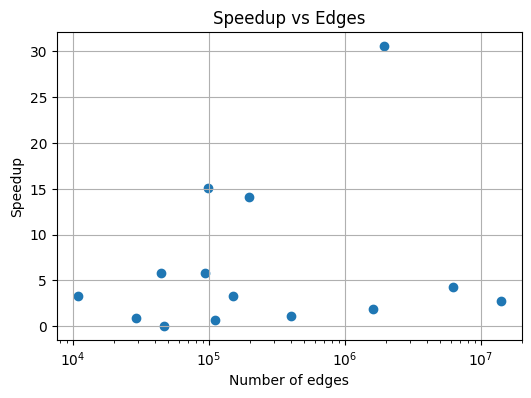

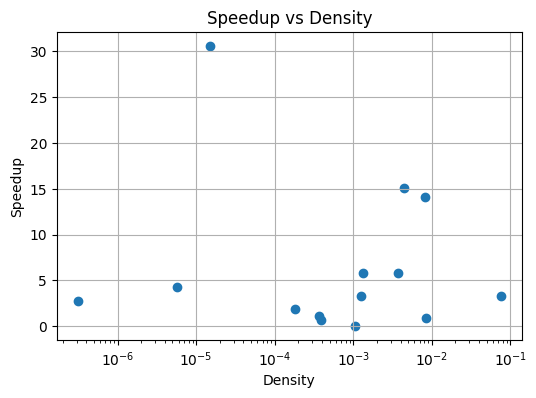

In [11]:
import matplotlib.pyplot as plt

df = results_df.sort_values("nodes")

plt.figure(figsize=(6, 4))

plt.scatter(
    df["nodes"],
    df["speedup"]
)

plt.xscale("log")

plt.xlabel("Number of vertices")
plt.ylabel("Speedup")
plt.title("Speedup vs Nodes")
plt.grid(True)

plt.show()

plt.figure(figsize=(6, 4))

plt.scatter(
    df["edges"].sort_values(),
    df["speedup"]
)

plt.xscale("log")

plt.xlabel("Number of edges")
plt.ylabel("Speedup")
plt.title("Speedup vs Edges")
plt.grid(True)

plt.show()

df_density = results_df.sort_values("density")

plt.figure(figsize=(6, 4))

plt.scatter(
    df_density["density"],
    df_density["speedup"]
)

plt.xscale("log")

plt.xlabel("Density")
plt.ylabel("Speedup")
plt.title("Speedup vs Density")
plt.grid(True)

plt.show()

Видим, что явных зависимостей между кол-вом вершин, ребер и разреженностью графа нет. Т.е. скорее всего ускорение зависит либо от других параметров, либо от комбинации этих.

При этом зависимости ускорения от кол-ва вершин и ребер очень похожи.